In [23]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression
from adjustText import adjust_text
from sklearn.cluster import MiniBatchKMeans
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon
from maia2 import model, inference

In [24]:
with open('final_data.pkl', 'rb') as file:
    data = pickle.load(file)

In [25]:
x_acc = []
y_acc = []
z_acc = []

x_std = []
y_std = []
z_std = []

In [26]:
# Calculate the accuracy and standard deviation of move probabilities for each player across game phases
for player, player_data in data.items():
    opening_acc_cumul = 0
    opening_probs = []
    for index, move in player_data[0].iterrows():
        for predicted_move, probability in move['move_probs'].items():
            if predicted_move == move['move']: # Find probability of actual move
                opening_acc_cumul += probability
                opening_probs.append(probability)
    opening_acc = opening_acc_cumul/len(player_data[0])  # Average over all moves
    opening_std = np.std(opening_probs)  # Standard deviation over all moves
    
    middle_acc_cumul = 0
    middle_probs = []
    for index, move in player_data[2].iterrows():
        for predicted_move, probability in move['move_probs'].items():
            if predicted_move == move['move']: 
                middle_acc_cumul += probability
                middle_probs.append(probability)
    middle_acc = middle_acc_cumul/len(player_data[2])  
    middle_std = np.std(middle_probs)
    
    end_acc_cumul = 0
    end_probs = []
    for index, move in player_data[4].iterrows():
        for predicted_move, probability in move['move_probs'].items():
            if predicted_move == move['move']:
                end_acc_cumul += probability
                end_probs.append(probability)
    end_acc = end_acc_cumul/len(player_data[4])  
    end_std = np.std(end_probs)
    
    x_acc.append(opening_acc)
    y_acc.append(middle_acc)
    z_acc.append(end_acc)
    
    x_std.append(opening_std)
    y_std.append(middle_std)
    z_std.append(end_std)

In [27]:
# PCA to reduce dimensionality for both datasets
X_acc = np.array([x_acc, y_acc, z_acc]).T
pca_acc = PCA(n_components=3)
X_acc_pca = pca_acc.fit_transform(X_acc)
pc1_acc_variance_ratio = pca_acc.explained_variance_ratio_[0]

X_std = np.array([x_std, y_std, z_std]).T
pca_std = PCA(n_components=3)
X_std_pca = pca_std.fit_transform(X_std)
pc1_std_variance_ratio = pca_acc.explained_variance_ratio_[0]

In [28]:
# Show PCA on 3d plots
mean_acc = np.mean(X_acc, axis=0)
pc1_acc = pca_acc.components_[0]
start_acc = mean_acc - 0.037 * pc1_acc
end_acc = mean_acc + 0.037 * pc1_acc

mean_std = np.mean(X_std, axis=0)
pc1_std = pca_std.components_[0]
start_std = mean_std - 0.01 * pc1_std
end_std = mean_std + 0.01 * pc1_std

In [29]:
# Regression between PC1 and each phase scores
r2_values = []
for name, values in zip(['Opening', 'Middle', 'End'], [x_acc, y_acc, z_acc]):
    reg = LinearRegression().fit(X_acc_pca[:, 0].reshape(-1, 1), values)
    r2 = reg.score(X_acc_pca[:, 0].reshape(-1, 1), values)
    r2_values.append(r2)
    print(f'{name} phase: R^2 = {r2:.2f}')
r2_label =(
    "R² with PC1:\n"
    f"  • Opening = {r2_values[0]:.2f}\n"
    f"  • Middle = {r2_values[1]:.2f}\n"
    f"  • Endgame = {r2_values[2]:.2f}"
)

Opening phase: R^2 = 0.82
Middle phase: R^2 = 0.83
End phase: R^2 = 0.80


In [30]:
def annotate_3d(ax, x, y, z, text, x_offset=0, y_offset=0, z_offset=0, size=8, zorder=2, color='k', ha='center'):
    ax.text(x + x_offset, y + y_offset, z + z_offset, text, size=size, zorder=zorder, color=color, ha=ha)

def annotate_and_arrow_3d(ax, x, y, z, text, x_offset=0, y_offset=0, z_offset=0,  size=8, zorder=2, color='k', ha='center'):
    annotate_3d(ax, x + x_offset, y + y_offset, z + z_offset, text, size=size, zorder=zorder, color=color, ha=ha)
    
    ax.quiver(
        x + x_offset, y + y_offset, z + 0.0005,
        -x_offset, -y_offset, -0.0005,
        color='black',
        linewidth=0.8,
        arrow_length_ratio=0,
        alpha=0.8)

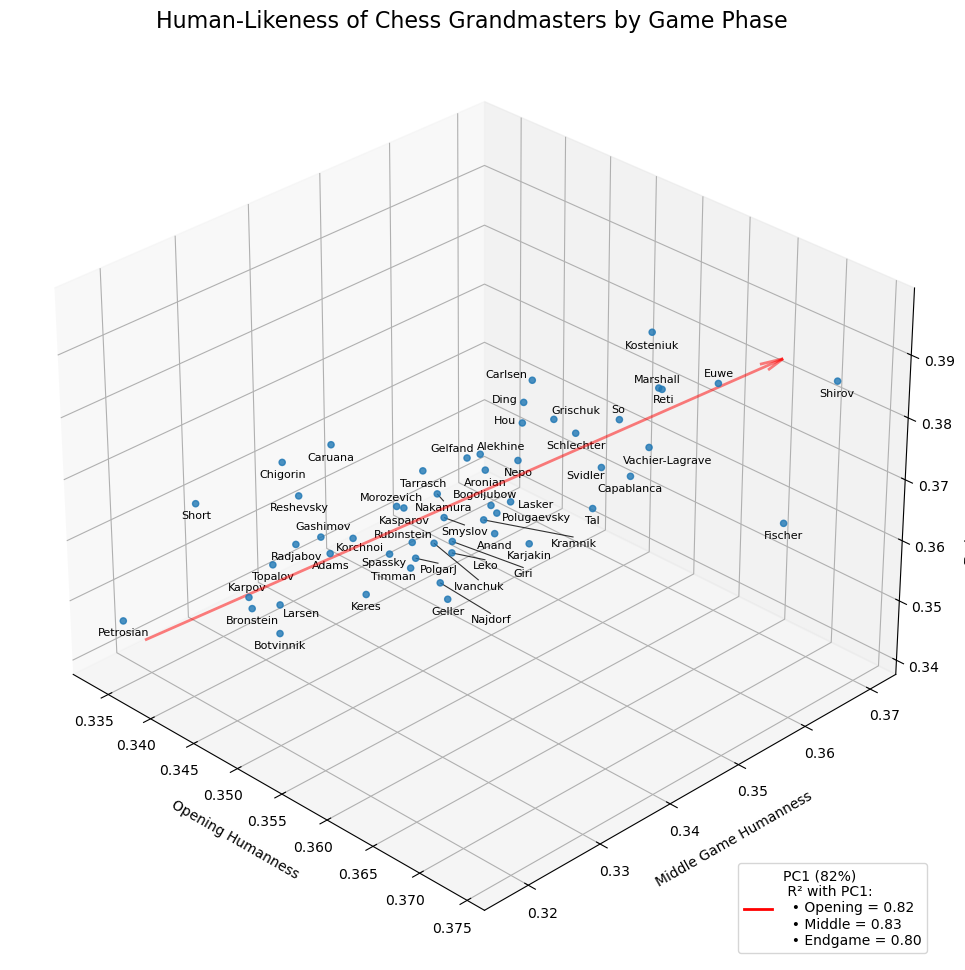

In [31]:
fig_3d_acc = plt.figure(1, figsize=(12, 12))
ax_acc = plt.axes(projection='3d', proj_type='persp')
ax_acc.scatter(x_acc, y_acc, z_acc, alpha=0.8)
    
for i, player in enumerate(data.keys()):
    if player == 'VachierLagrave':
        player = 'Vachier-Lagrave'
    if player == 'Nepomniachtchi':
        player = 'Nepo'
        
    # Custom text placements for certain players to avoid overlap
    if player == 'Gashimov':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=0.0003, z_offset=0.0014)
        continue
    if player == 'Karpov':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=-0.0002, z_offset=0.001)
        continue   
    if player == 'Timman':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=-0.002, z_offset=-0.0035)
        continue
    if player == 'Larsen':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=0.0025)
        continue
    if player == 'PolgarJ':
        annotate_and_arrow_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=0.0021, y_offset=0.0005, z_offset=-0.001)
        continue
    if player == 'Leko':
        annotate_and_arrow_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=0.0029, y_offset=0.001, z_offset=-0.001)
        continue
    if player == 'Smyslov':
        annotate_and_arrow_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=0.0023, z_offset=-0.001)
        continue
    if player == 'Spassky':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=-0.0007, z_offset=-0.0025)
        continue
    if player == 'Korchnoi':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=0.0007, z_offset=-0.0015)
        continue
    if player == 'Morozevich':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=-0.0006, z_offset=0.0005)
        continue
    if player == 'Nakamura':
        annotate_and_arrow_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=0.0015, y_offset=-0.001, z_offset=-0.001)
        continue
    if player == 'Rubinstein':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=-0.001, z_offset=0.000)
        continue
    if player == 'Ivanchuk':
        annotate_and_arrow_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=0.0066, y_offset=-0.0023, z_offset=-0.001)
        continue
    if player == 'Giri':
        annotate_and_arrow_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=0.007, y_offset=0.001, z_offset=-0.001)
        continue
    if player == 'Gelfand':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=-0.0017, z_offset=-0.0002)
        continue
    if player == 'Alekhine':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=0.0023, z_offset=0.0025)
        continue
    if player == 'Grischuk':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=0.0023, z_offset=0.0025)
        continue
    if player == 'Grischuk':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=0.0023, z_offset=0.0025)
        continue
    if player == 'Bogoljubow':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=-0.0006, z_offset=0.0008)
        continue
    if player == 'Hou':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=-0.0019, z_offset=-0.0015)
        continue
    if player == 'Ding':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=-0.0021, z_offset=-0.0015)
        continue
    if player == 'Carlsen':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=-0.0028, z_offset=-0.0015)
        continue
    if player == 'Lasker':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=0.0027, z_offset=0.001)
        continue
    if player == 'Polugaevsky':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=0.0043, z_offset=0.002)
        continue
    if player == 'Kramnik':
        annotate_and_arrow_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=0.007, y_offset=0.0035, z_offset=-0.001)
        continue
    if player == 'Najdorf':
        annotate_and_arrow_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=0.0063, y_offset=-0.001, z_offset=-0.001)
        continue
    if player == 'So':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=-0.0001, z_offset=0.001)
        continue
    if player == 'Svidler':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=-0.0016, z_offset=-0.003)
        continue
    if player == 'Vachier-Lagrave':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=0.002, z_offset=-0.0012)
        continue
    if player == 'Marshall':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=-0.0002, z_offset=0.0008)
        continue
    if player == 'Reti':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, x_offset=0.0002, z_offset=-0.002)
        continue
    if player == 'Euwe':
        annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, z_offset=0.001)
        continue
    
    annotate_3d(ax_acc, x_acc[i], y_acc[i], z_acc[i], player, z_offset=-0.0025)


ax_acc.set_xlabel('Opening Humanness', labelpad=8)
ax_acc.set_ylabel('Middle Game Humanness', labelpad=8)
ax_acc.set_zlabel('End Game Humanness', labelpad=8)
ax_acc.set_title('Human-Likeness of Chess Grandmasters by Game Phase', size=16)

ax_acc.quiver(
    start_acc[0], start_acc[1], start_acc[2],
    end_acc[0] - start_acc[0],
    end_acc[1] - start_acc[1],
    end_acc[2] - start_acc[2],
    color='red',
    linewidth=2,
    arrow_length_ratio=0.03,
    alpha=0.5
)

# Add a legend for PCA component 1
red_line = Line2D([0], [0], color='red', lw=2, label=f'PC1 ({pc1_acc_variance_ratio:.0%})\n {r2_label}')
ax_acc.legend(handles=[red_line], loc='lower right', fontsize=10)


ax_acc.view_init(elev=30, azim=-45)

plt.savefig('human_likeness_3d.png', dpi=300, bbox_inches='tight', pad_inches=0.3)


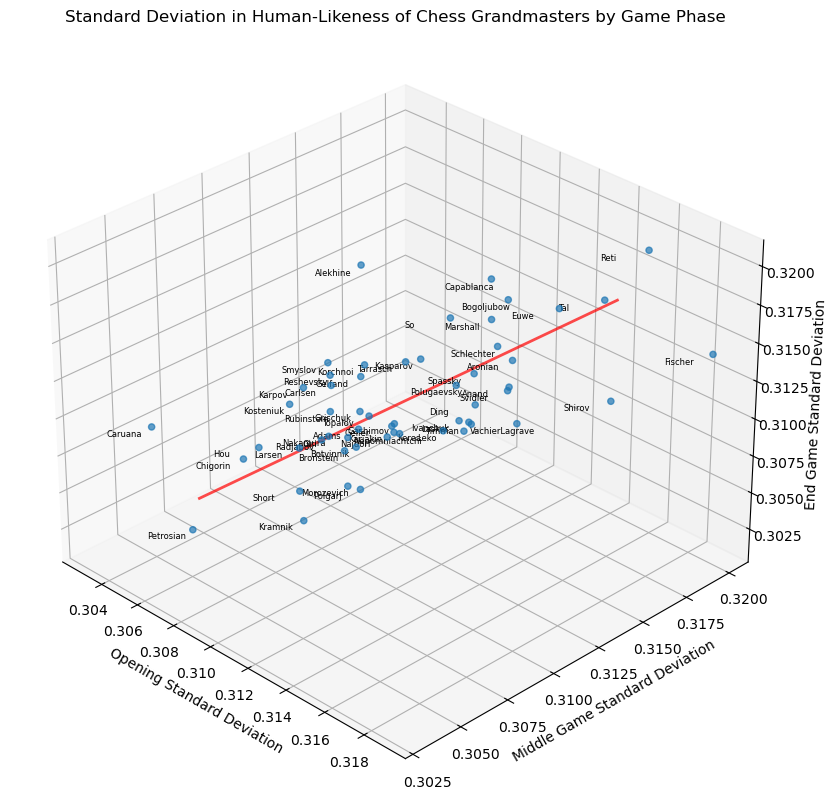

In [32]:
fig_3d_std = plt.figure(2, figsize=(10, 10))
ax_std = plt.axes(projection='3d', proj_type='persp')
ax_std.scatter(x_std, y_std, z_std, alpha=0.7)

for i, player in enumerate(data.keys()):
    ax_std.text(x_std[i] - 0.0015, y_std[i] - 0.001, z_std[i] - 0.001, player, size=6, zorder=2, color='k')

ax_std.set_xlabel('Opening Standard Deviation')
ax_std.set_ylabel('Middle Game Standard Deviation')
ax_std.set_zlabel('End Game Standard Deviation')
ax_std.set_title('Standard Deviation in Human-Likeness of Chess Grandmasters by Game Phase')

ax_std.plot([start_std[0], end_std[0]], 
            [start_std[1], end_std[1]], 
            [start_std[2], end_std[2]], color='red', linewidth=2, zorder=1, alpha=0.7, label='PCA Component 1')

ax_std.view_init(elev=30, azim=-45)

plt.savefig('std_dev_human_likeness_3d.png', dpi=300, bbox_inches='tight', pad_inches=0.3)

Petrosian -0.03655890218270808
Botvinnik -0.02831855159230781
Larsen -0.02551277208007713
Bronstein -0.025146020202104113
Karpov -0.0242086462436965
Short -0.019498964370279658
Topalov -0.018625322145810804
Keres -0.017671997492752563
Adams -0.016389960193036644
Radjabov -0.014555672403622807
Spassky -0.01185105858817262
Reshevsky -0.01182056491487498
Timman -0.011741817251244836
Gashimov -0.01125072047521251
Korchnoi -0.010186423014066366
Geller -0.009811115599331243
Chigorin -0.00884347205450352
Najdorf -0.007969660106609027
Rubinstein -0.0058477512635118165
PolgarJ -0.00580199777271659
Leko -0.004436495150711735
Morozevich -0.004161911007519098
Kasparov -0.004015318946768375
Giri -0.004014371222145277
Caruana -0.0034908103393619027
Ivanchuk -0.0032833667992704773
Smyslov -0.003020770834086747
Polugaevsky -0.0007114612122780771
Nakamura 0.00025624625433507
Bogoljubow 0.0004292244366493649
Tarrasch 0.000909627098224832
Kramnik 0.0013972555362924794
Aronian 0.0024898370298325743
Anand 

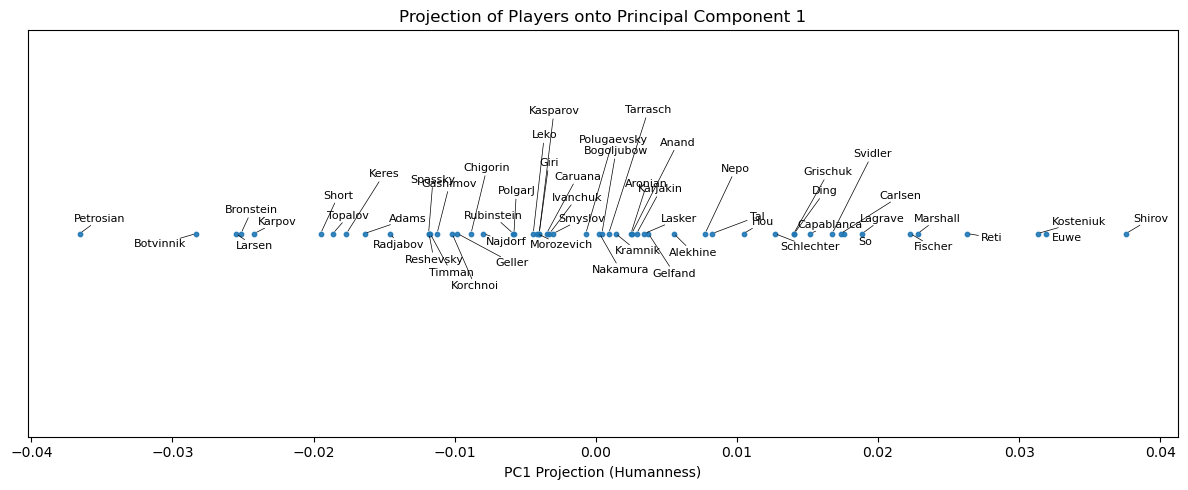

In [33]:
pc1_acc_values = X_acc_pca[:, 0]

fig_1d_acc = plt.figure(3, figsize=(12, 5))
zeros = np.zeros(len(pc1_acc_values))
plt.scatter(pc1_acc_values, zeros, s=10, alpha=0.9)

sorted_pairs = sorted(zip(pc1_acc_values, data.keys()))
pc1_acc_values_sorted = [val for val, _ in sorted_pairs]
players_acc_order = [player for _, player in sorted_pairs]

texts_1d_acc = []

for i, player in enumerate(players_acc_order):
    if player == 'VachierLagrave':
        player = 'Lagrave'
    if player == 'Nepomniachtchi':
        player = 'Nepo'
        
    if i % 2 == 0:
        texts_1d_acc.append(plt.text(pc1_acc_values_sorted[i], 0, player, rotation=0, ha='center', va='bottom', fontsize=8))
    else:
        texts_1d_acc.append(plt.text(pc1_acc_values_sorted[i], 0, player, rotation=0, ha='center', va='top', fontsize=8))
    print(player, pc1_acc_values_sorted[i])

adjust_text(texts_1d_acc, arrowprops=dict(arrowstyle='-', color='black', lw=0.5), time_lim=10, force_static=(5, 10), force_text=(0.1, 5), ensure_inside_axes=False, force_explode=(1, 300))

plt.yticks([])
plt.xlabel('PC1 Projection (Humanness)')
plt.title('Projection of Players onto Principal Component 1')
plt.tight_layout()

plt.savefig('pc1_projection.png', dpi=300, bbox_inches='tight', pad_inches=0.3)

In [34]:
pc1_std_values = X_std_pca[:, 0]

# 2d clustering of players based on PCA components
points = np.column_stack((pc1_acc_values, pc1_std_values))

n_clusters = 8
kmeans = MiniBatchKMeans(n_clusters=n_clusters, n_init=10, random_state=0)
labels = kmeans.fit_predict(points)

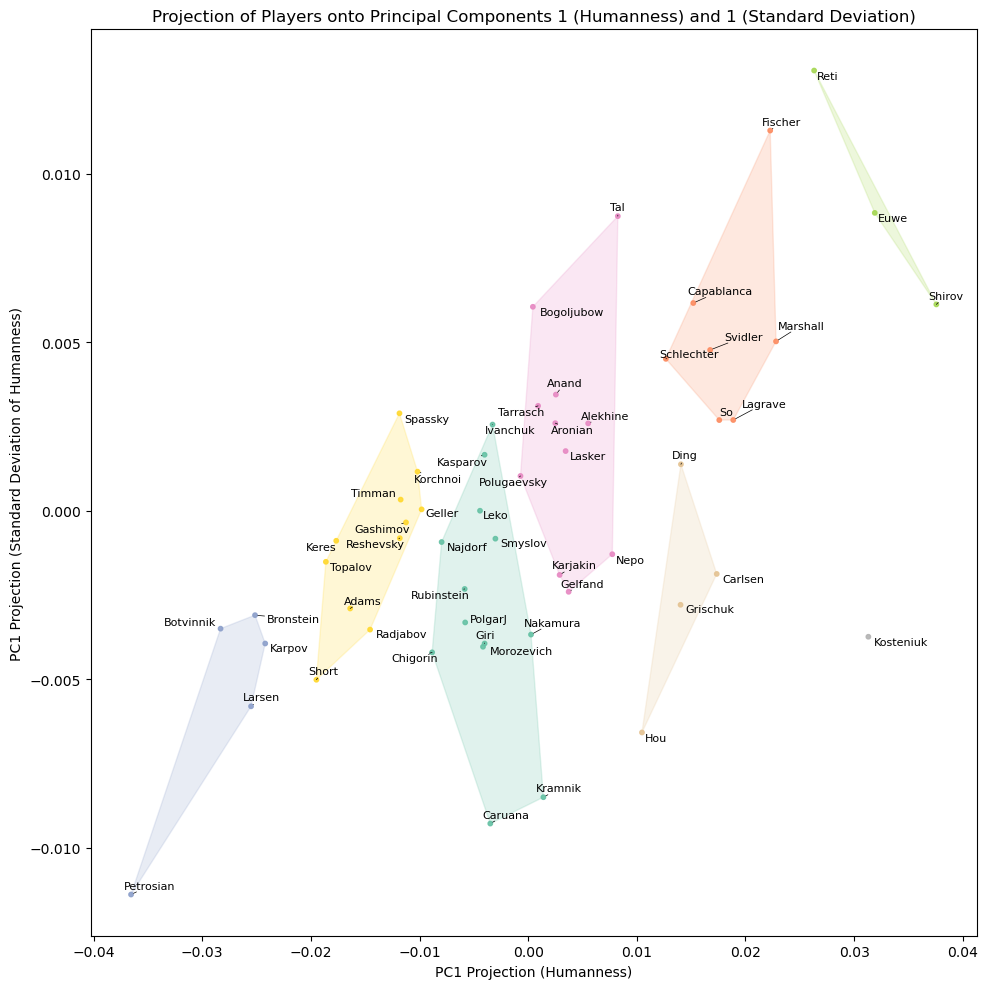

In [35]:

fig_2d = plt.figure(4, figsize=(10, 10))
scatter = plt.scatter(pc1_acc_values, pc1_std_values, c=labels, cmap='Set2', s=10, alpha=0.9)

for cluster_id in range(n_clusters):
    cluster_points = points[labels == cluster_id]
    
    if len(cluster_points) >= 3:
        hull = ConvexHull(cluster_points)
        vertices = cluster_points[hull.vertices]
        polygon = Polygon(vertices, alpha=0.2, color=scatter.cmap(cluster_id), edgecolor='k')
        plt.gca().add_patch(polygon)

texts_2d = []

for i, player in enumerate(data.keys()):
    if player == 'VachierLagrave':
        player = 'Lagrave'
    if player == 'Nepomniachtchi':
        player = 'Nepo'
        
    if i % 2 == 0:
        texts_2d.append(plt.text(pc1_acc_values[i], pc1_std_values[i], player, rotation=0, ha='center', va='bottom', fontsize=8))
    else:
        texts_2d.append(plt.text(pc1_acc_values[i], pc1_std_values[i], player, rotation=0, ha='center', va='top', fontsize=8))

adjust_text(texts_2d, arrowprops=dict(arrowstyle='-', color='black', lw=0.5), time_lim=3)

plt.xlabel('PC1 Projection (Humanness)')
plt.ylabel('PC1 Projection (Standard Deviation of Humanness)')
plt.title('Projection of Players onto Principal Components 1 (Humanness) and 1 (Standard Deviation)')
plt.tight_layout()

In [36]:
maia2_model = model.from_pretrained(type="rapid", device="cpu")

Model for rapid games already downloaded.
Model for rapid games loaded to cpu.


In [37]:
x_test_acc = []
y_test_acc = []
z_test_acc = []
x_test_std = []
y_test_std = []
z_test_std = []

In [38]:
for player, player_data in data.items():
    # if not (player == 'Shirov' or player == 'Tarrasch' or player == 'Kramnik'):
    #     continue
    opening_test_data, opening_acc = inference.inference_batch(player_data[1], maia2_model, verbose=0, batch_size=128, num_workers=0)
    middle_test_data, mid_acc = inference.inference_batch(player_data[3], maia2_model, verbose=0, batch_size=128, num_workers=0)
    end_test_data, end_acc = inference.inference_batch(player_data[5], maia2_model, verbose=0, batch_size=128, num_workers=0)
    
    opening_acc_cumul = 0
    opening_probs = []
    for index, move in opening_test_data.iterrows():
        for predicted_move, probability in move['move_probs'].items():
            if predicted_move == move['move']: # Find probability of actual move
                opening_acc_cumul += probability
                opening_probs.append(probability)
    opening_acc = opening_acc_cumul/len(player_data[1])  # Average over all moves
    opening_std = np.std(opening_probs)  # Standard deviation over all moves
    
    middle_acc_cumul = 0
    middle_probs = []
    for index, move in middle_test_data.iterrows():
        for predicted_move, probability in move['move_probs'].items():
            if predicted_move == move['move']: 
                middle_acc_cumul += probability
                middle_probs.append(probability)
    middle_acc = middle_acc_cumul/len(player_data[3])  
    middle_std = np.std(middle_probs)
    
    end_acc_cumul = 0
    end_probs = []
    for index, move in end_test_data.iterrows():
        for predicted_move, probability in move['move_probs'].items():
            if predicted_move == move['move']:
                end_acc_cumul += probability
                end_probs.append(probability)
    end_acc = end_acc_cumul/len(player_data[5])  
    end_std = np.std(end_probs)
    
    x_test_acc.append(opening_acc)
    y_test_acc.append(middle_acc)
    z_test_acc.append(end_acc)
    
    x_test_std.append(opening_std)
    y_test_std.append(middle_std)
    z_test_std.append(end_std)

In [39]:
player_humanness_values = [(x_acc[i], y_acc[i], z_acc[i]) for i in range(len(data.keys()))]

In [42]:
top1 = 0
top3 = 0
top5 = 0

for i in range(len(data.keys())):
    player = list(data.keys())[i]
    test_point_acc = np.array([x_test_acc[i], y_test_acc[i], z_test_acc[i]])
    distances = np.linalg.norm(player_humanness_values - test_point_acc, axis=1)
    
    sorted_indices = np.argsort(distances)
    
    k = 5
    
    for j in range(k):
        idx = sorted_indices[j]
        print(f"{j+1} to {player}. {list(data.keys())[idx]} - Distance: {distances[idx]:.4f}")
        if player == list(data.keys())[idx]:
            if j==0:
                top1 += 1
                top3 += 1
                top5 += 1
            elif j <= 2:
                top3 += 1
                top5 += 1
            elif j <=4:
                top5 += 1
            break
    print('\n')
print(f'Top 1: {top1}, top 3: {top3}, top 5: {top5}')

1 to Shirov. Shirov - Distance: 0.0058


1 to Tarrasch. Morozevich - Distance: 0.0027
2 to Tarrasch. Kasparov - Distance: 0.0035
3 to Tarrasch. Korchnoi - Distance: 0.0052
4 to Tarrasch. Rubinstein - Distance: 0.0061
5 to Tarrasch. Nakamura - Distance: 0.0067


1 to Kramnik. Timman - Distance: 0.0027
2 to Kramnik. Spassky - Distance: 0.0028
3 to Kramnik. Adams - Distance: 0.0075
4 to Kramnik. Keres - Distance: 0.0078
5 to Kramnik. Geller - Distance: 0.0082


1 to Geller. Timman - Distance: 0.0091
2 to Geller. Spassky - Distance: 0.0100
3 to Geller. Polugaevsky - Distance: 0.0113
4 to Geller. Keres - Distance: 0.0120
5 to Geller. Adams - Distance: 0.0127


1 to Nakamura. Smyslov - Distance: 0.0048
2 to Nakamura. Giri - Distance: 0.0068
3 to Nakamura. Bogoljubow - Distance: 0.0073
4 to Nakamura. Kasparov - Distance: 0.0077
5 to Nakamura. Spassky - Distance: 0.0079


1 to Rubinstein. Gelfand - Distance: 0.0032
2 to Rubinstein. Alekhine - Distance: 0.0046
3 to Rubinstein. Aronian - Distanc

In [41]:
print(len(data.keys()))

55
